In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
import pickle

#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4
Running on PyMC3 v3.11.4


In [5]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [6]:
data = pd.read_csv("data_bt_dem.csv")
participantcode = data.participant.unique()
data["confidence_BT"] = data["confidence_BT"]*0.1
data["confidence_BT"] = data["confidence_BT"].astype(theano.config.floatX)

In [7]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}

median_conf=data["confidence_BT"].median()
hr_null= pm.Model(coords=coords) 

with hr_null:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a_null", mu=median_conf, sigma=5,testval=0.0)
    sigma_a = pm.HalfNormal("sigma_a_null", 5,testval=1)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a_null", mu=mu_a, sigma=sigma_a, dims="participant")    

    # Model spec
    eps = pm.HalfCauchy("eps_null", 5)
    confidence_BT_est_null = (a[participant_idx])

    # Data likelihood
    confidence_BT_like_null = pm.Normal(
        "confidence_BT_like_null", mu=confidence_BT_est_null, sigma=eps, observed=data.confidence_BT, dims="obs_id",testval=median_conf)
    
with hr_null:
    hr_null_trace = pm.sample(10000,tune=10000, target_accept=0.9, return_inferencedata=True) 

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps_null, a_null, sigma_a_null, mu_a_null]


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 66 seconds.


0, dim: obs_id, 1357 =? 1357


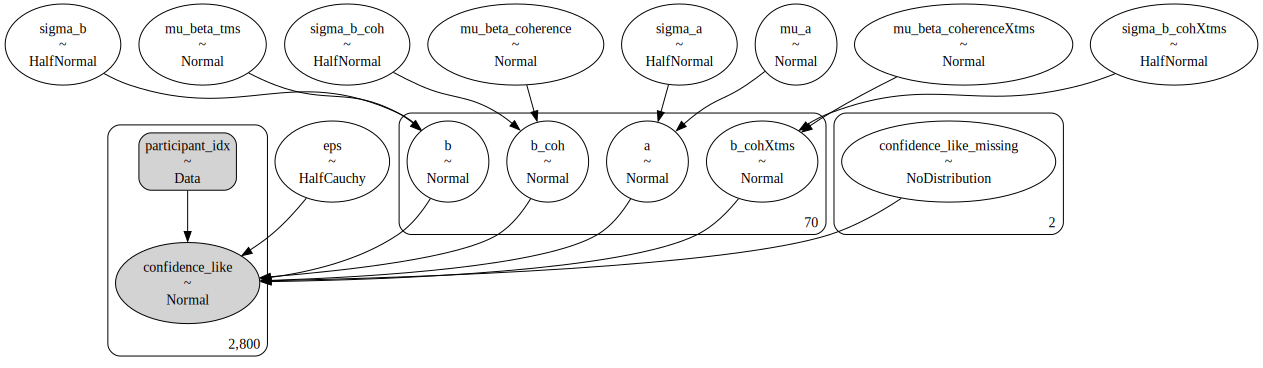

In [59]:
pm.model_to_graphviz(hr_conf)

In [8]:
# Save the model
with open('hr_null_bt.pkl', 'wb') as file:
    pickle.dump(hr_null, file)
    
hr_null_trace.to_netcdf('hr_null__bt_trace.nc', compress=False)

'hr_null__bt_trace.nc'

In [4]:
# Load the model from the pickled file
with open('hr_null_bt.pkl', 'rb') as file:
    hr_null_rdm = pickle.load(file)

hr_null_trace = az.from_netcdf('hr_null__bt_trace.nc')


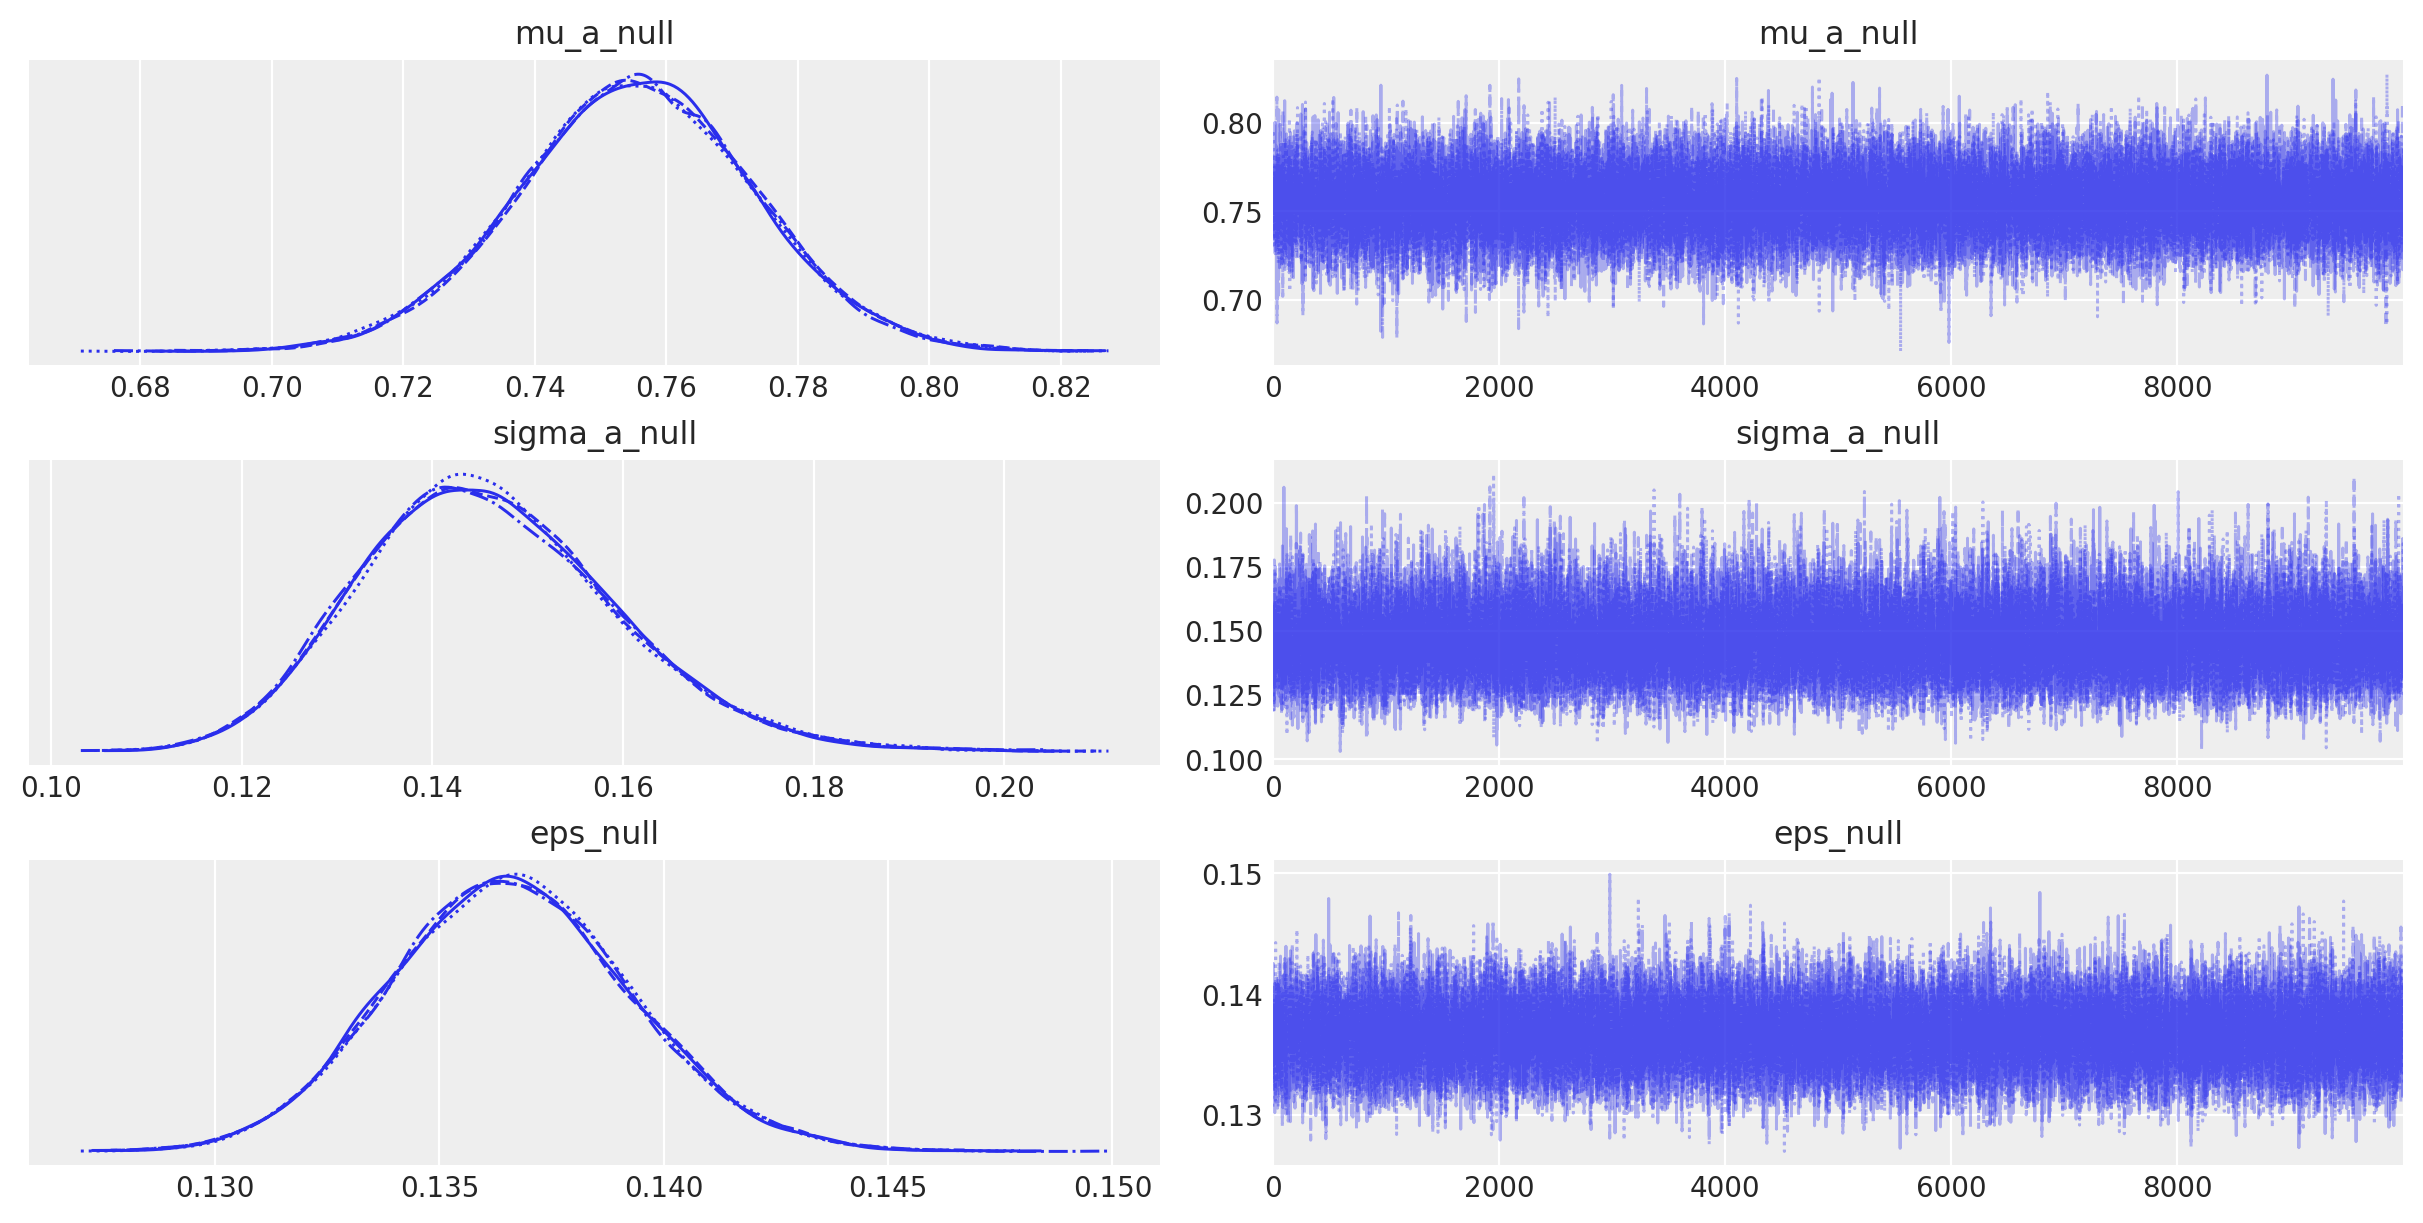

In [9]:
az.plot_trace(hr_null_trace, 
              var_names=["mu_a_null","sigma_a_null","eps_null"]);


In [11]:
# Load the model from the pickled file
with open('hr_null_bt.pkl', 'rb') as file:
    hr_null = pickle.load(file)

hr_null_trace = az.from_netcdf('hr_null__bt_trace.nc')


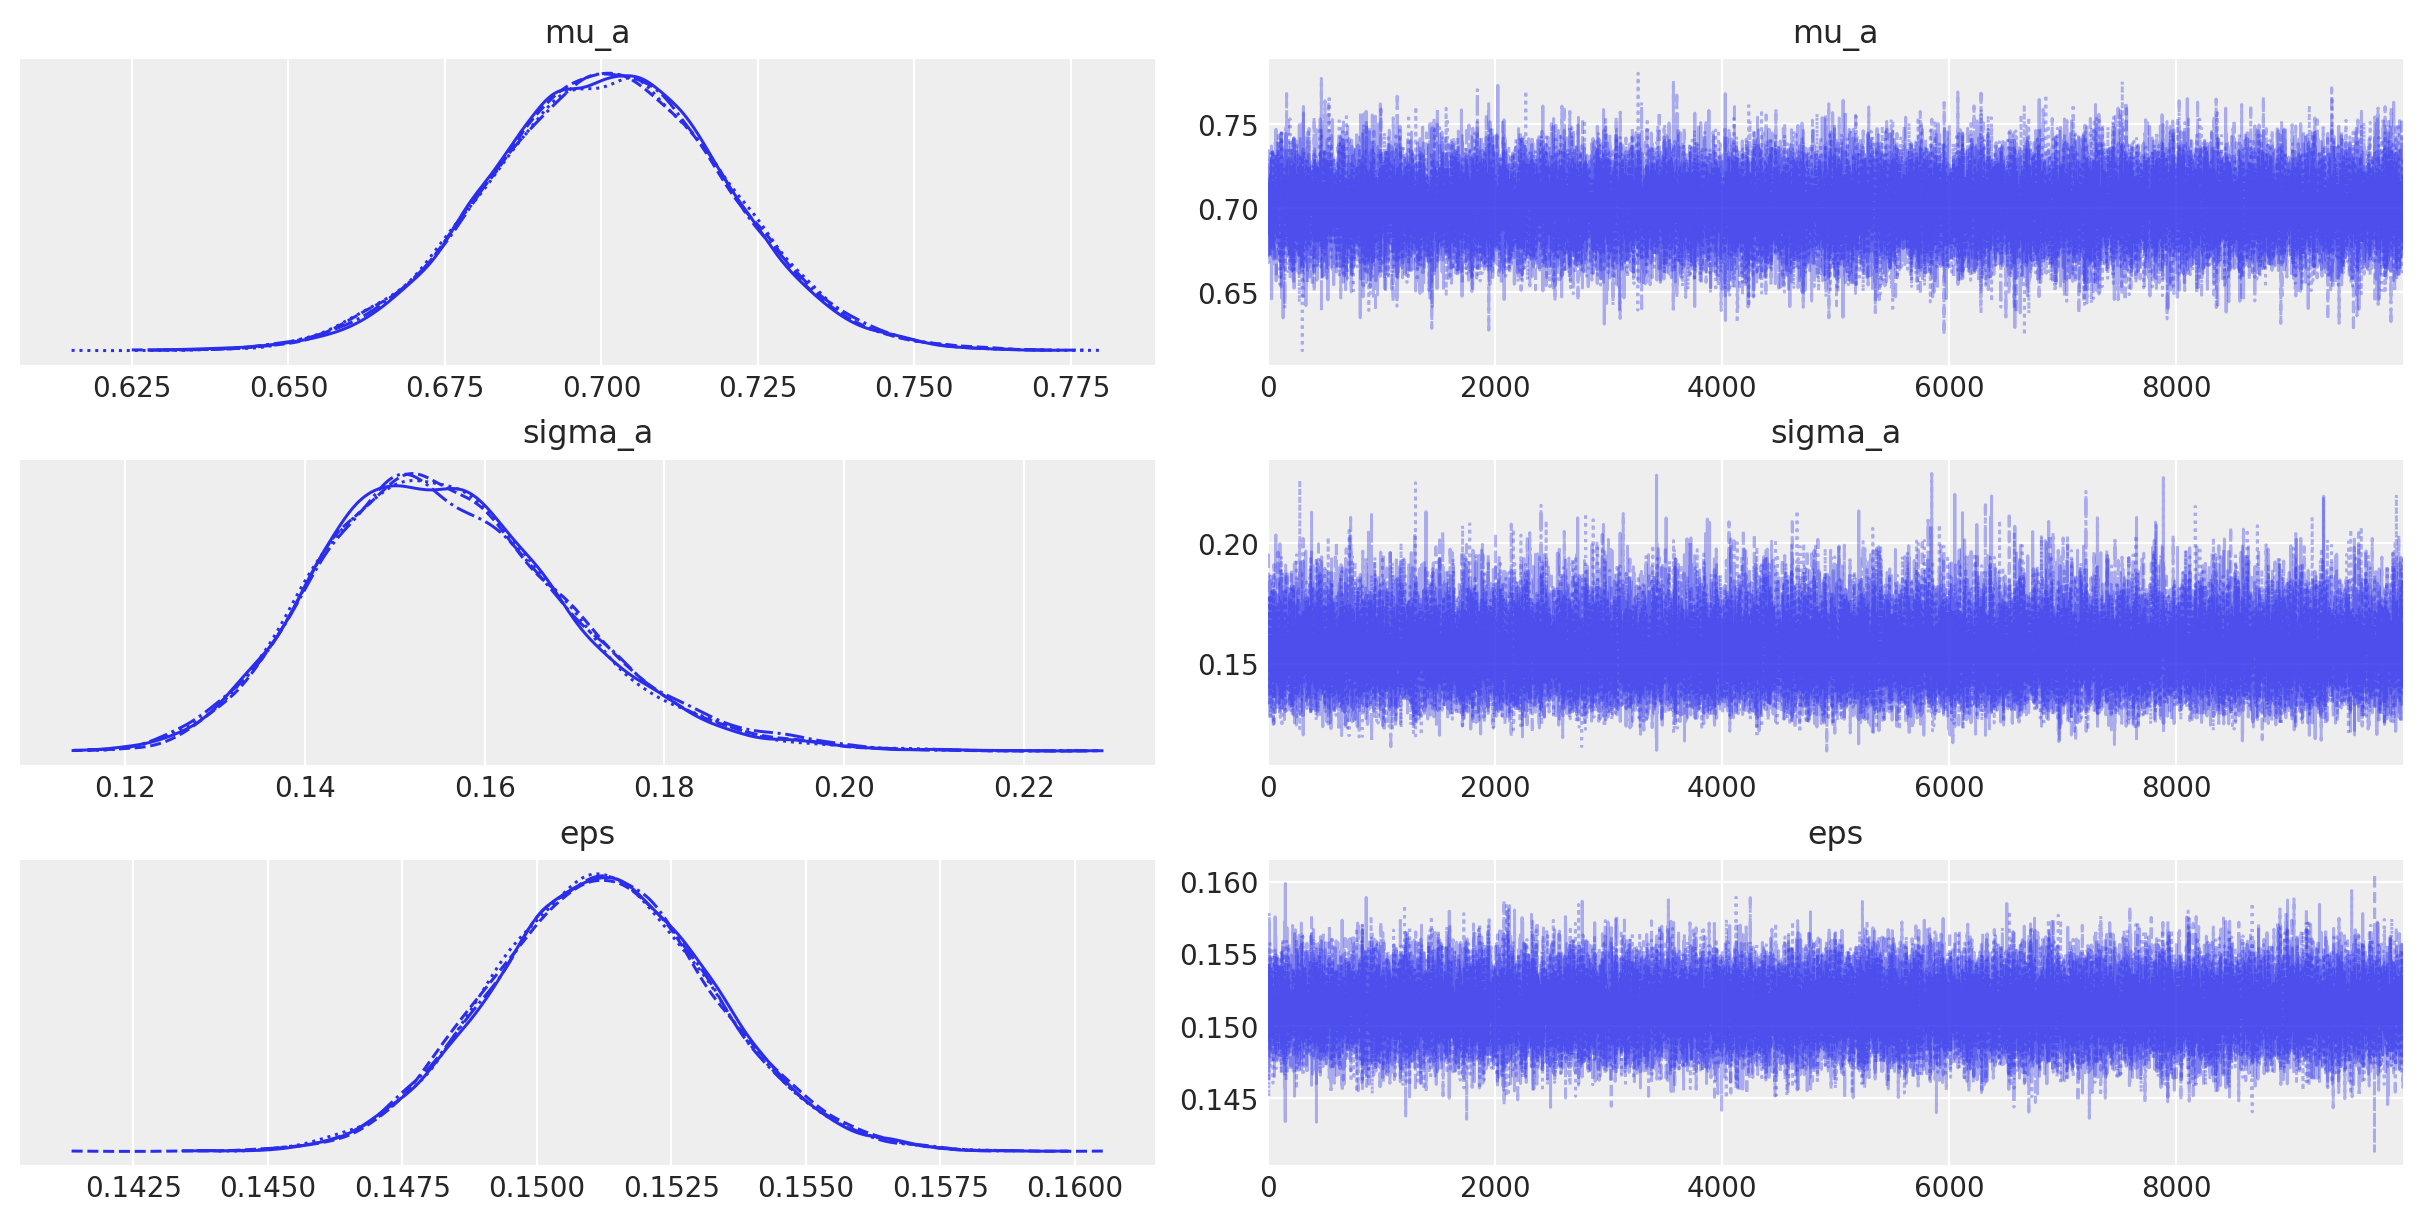

In [6]:
az.plot_trace(hr_null_trace, 
              var_names=["mu_a", "sigma_a","eps"],
              );


In [5]:

# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_null_trace.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = log_likelihood.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_null_trace).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_null_trace, scale='deviance').waic

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



Log likelihood: <xarray.DataArray 'draw' ()>
array(4999.5)
Marginal likelihood (Log pointwise predictive density): <xarray.Dataset>
Dimensions:                  ()
Data variables:
    confidence_BT_like_null  float64 3.106e+07
Effective number of parameters (p_waic): 66.20429247681098
WAIC: -1483.8559448870742


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



In [14]:
hierarchical_loo = az.loo(hr_null_trace, hr_null)

hierarchical_loo.loo

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:781: UserWarning:

rename 'sample' to 'sample' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.



1250.7837154387973

In [10]:
with hr_null:
    posterior_pred= pm.sample_posterior_predictive(
        hr_null_trace, var_names=["a", "confidence_BT_like_null"])

KeyError: 'confidence_BT_like_null'

In [12]:
observed_data = data['confidence_BT']  # Replace with your actual observed data
predicted_data=np.abs(posterior_pred['confidence_BT_like_null'])
deviances = -2 * np.sum(np.log(predicted_data), axis=1)

pD = np.mean(deviances) - deviances.mean()
DIC = pD + np.mean(deviances)
print (DIC)

876.369972886985


In [3]:
print (deviances)

NameError: name 'deviances' is not defined

<Axes: xlabel='confidence_like'>

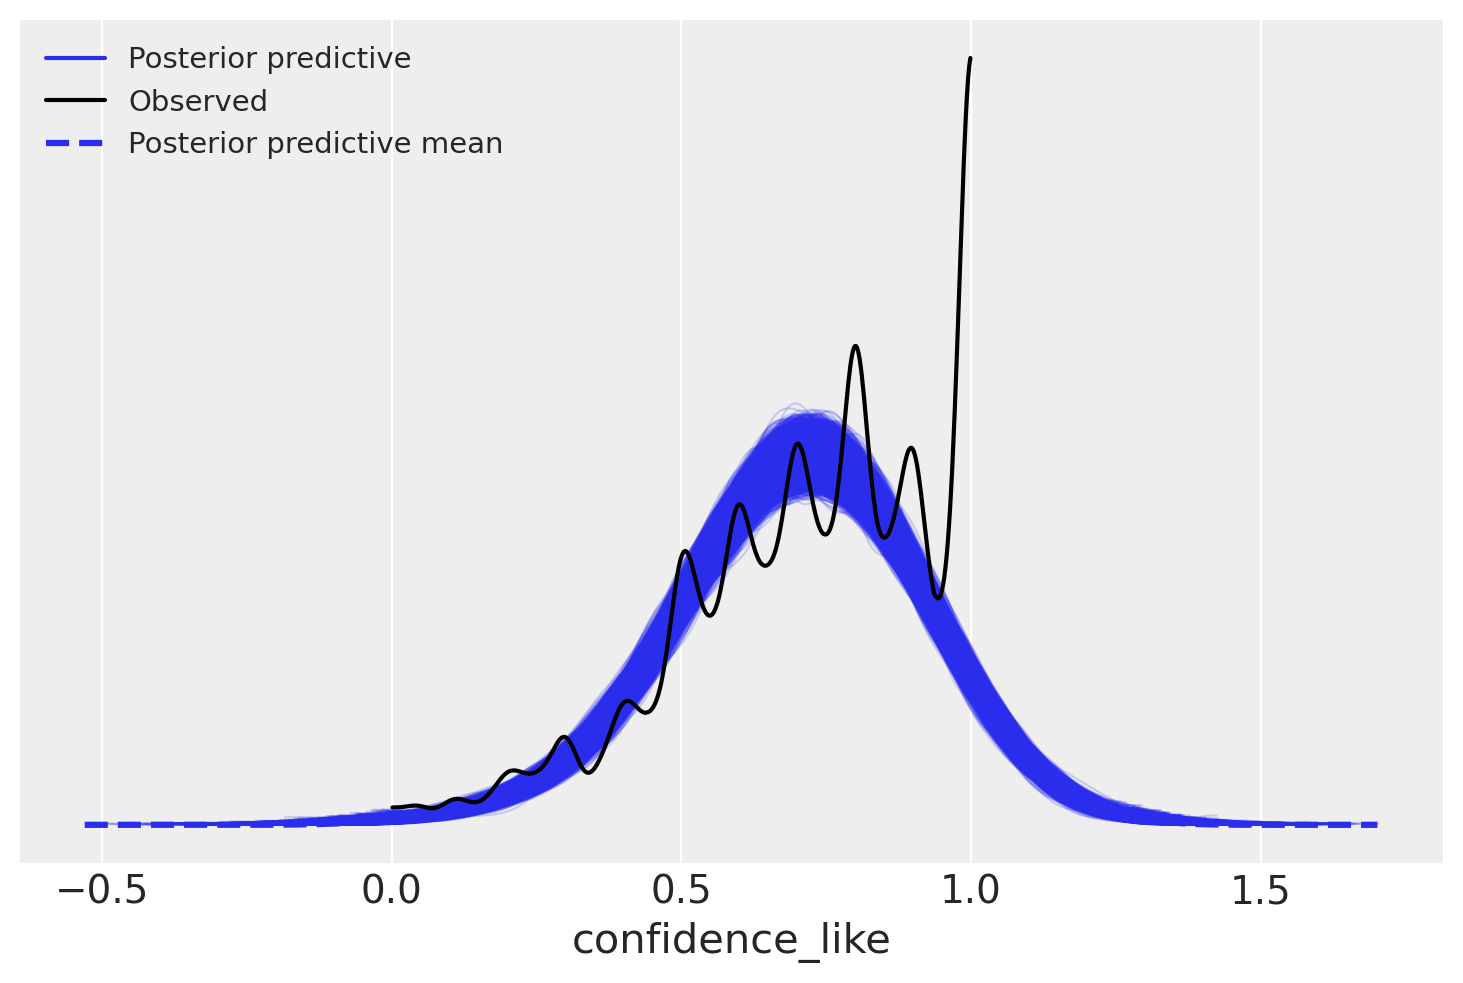

In [37]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_conf))

In [36]:
az.r2_score(data.confidence_BT.values, ppc_reg['confidence_BT_like'])

r2       NaN
r2_std   NaN
dtype: float64